In [1]:
import pandas as pd
import sklearn as sk

In [2]:
import pandas as pd
import glob

# Encontra todos os arquivos .csv no diretório atual
arquivos_csv = glob.glob('*.csv')

# Lista para armazenar os DataFrames temporários
lista_dfs = []

for arquivo in arquivos_csv:
    # Lê cada arquivo e adiciona à lista
    df_temp = pd.read_csv(arquivo)
    lista_dfs.append(df_temp)

# Verifica se a lista não está vazia antes de concatenar
if lista_dfs:
    # Concatena todos os DataFrames em um só
    # ignore_index=True garante que o índice final seja contínuo (0, 1, 2...)
    df_final = pd.concat(lista_dfs, ignore_index=True)
    print(f"Sucesso! {len(arquivos_csv)} arquivos concatenados.")
    print(df_final.head())
else:
    print("Nenhum arquivo .csv foi encontrado no diretório atual.")

Sucesso! 12 arquivos concatenados.
                                     id      lat      lon  \
0  966ed445-fa70-3369-9802-3e74c5765684 -12.5667 -41.4364   
1  0669c14d-7a39-3d98-9f20-23e118fbcf09 -12.5662 -41.4611   
2  53a46800-fa40-3323-9b20-05108d435c24 -18.0629 -57.3721   
3  7e692d84-dc67-348c-95e1-9e67a129b2db -18.0625 -57.3927   
4  267ae531-1d2c-3434-9280-7e3ba76fc896 -18.0629 -57.3721   

         data_hora_gmt satelite municipio              estado    pais  \
0  2024-01-01 00:00:00  GOES-16   LENÇÓIS               BAHIA  Brasil   
1  2024-01-01 00:00:00  GOES-16   LENÇÓIS               BAHIA  Brasil   
2  2024-01-01 00:00:00  GOES-16   CORUMBÁ  MATO GROSSO DO SUL  Brasil   
3  2024-01-01 00:00:00  GOES-16   CORUMBÁ  MATO GROSSO DO SUL  Brasil   
4  2024-01-01 01:00:00  GOES-16   CORUMBÁ  MATO GROSSO DO SUL  Brasil   

   municipio_id  estado_id  ...  quantidade_ocorrencias  temperatura  \
0       2919306         29  ...                       1         26.0   
1       2919306

In [3]:
df_final = df_final[(df_final['pais'] == 'Brasil') & ((df_final['bioma'] == 'Cerrado') | (df_final['bioma'] == 'Mata Atlântica'))]

In [4]:
df_final.columns

Index(['id', 'lat', 'lon', 'data_hora_gmt', 'satelite', 'municipio', 'estado',
       'pais', 'municipio_id', 'estado_id', 'pais_id', 'numero_dias_sem_chuva',
       'precipitacao', 'risco_fogo', 'bioma', 'frp', 'quantidade_ocorrencias',
       'temperatura', 'cobertura_nuvens', 'ponto_orvalho_2m', 'pressao_msl',
       'radiacao_direta', 'radiacao_ondas_curtas', 'umidade_solo_0_a_7cm',
       'temperatura_solo_0_a_7cm', 'rajadas_vento_10m'],
      dtype='str')

In [5]:
df_colunas_prontas = df_final[['temperatura', 'umidade_solo_0_a_7cm','bioma', 'risco_fogo']]

In [6]:
df_colunas_prontas.dropna(inplace=True)

In [7]:
df_colunas_prontas.columns = ['temperatura', 'umidade', 'bioma', 'risco_fogo']

In [8]:
df_colunas_prontas

,temperatura,umidade,bioma,risco_fogo
10,26.6,0.166,Mata Atlântica,1.0000
11,24.4,0.234,Mata Atlântica,0.4125
12,24.4,0.234,Mata Atlântica,0.5900
13,25.2,0.175,Mata Atlântica,0.3400
14,23.8,0.295,Mata Atlântica,0.7400
...,...,...,...,...
3247994,33.2,0.238,Mata Atlântica,0.8600
3247995,33.2,0.349,Cerrado,1.0000
3247996,33.8,0.358,Mata Atlântica,0.9600
3247997,33.2,0.349,Cerrado,1.0000


*pre-processamento*

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

df_preparado = pd.get_dummies(df_colunas_prontas, columns=['bioma'], drop_first=True)



In [10]:
X = df_preparado.drop('risco_fogo', axis=1)
y = df_preparado['risco_fogo']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

*arvore regressora*

In [11]:
modelo_arvore = DecisionTreeRegressor(random_state=42, max_depth=5)  # Definindo a profundidade máxima da árvore    
modelo_arvore.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``

In [12]:
previsoes = modelo_arvore.predict(X_test)

mse = mean_squared_error(y_test, previsoes)
mae = mean_absolute_error(y_test, previsoes)
r2 = r2_score(y_test, previsoes)

print(f"Erro Quadrático Médio (MSE): {mse:.4f}")
print(f"Erro Absoluto Médio (MAE): {mae:.4f}")
print(f"R² (Coeficiente de Determinação): {r2:.4f}")

Erro Quadrático Médio (MSE): 0.0577
Erro Absoluto Médio (MAE): 0.1520
R² (Coeficiente de Determinação): 0.3777


Tabela de Comparação (Primeiras 15 amostras):
    Valor Real  Previsão  Erro Absoluto
0         1.00  0.913578       0.086422
1         0.81  0.653628       0.156372
2         0.46  0.954452       0.494452
3         1.00  0.910495       0.089505
4         1.00  0.996461       0.003539
5         1.00  0.986543       0.013457
6         1.00  0.913578       0.086422
7         1.00  0.986543       0.013457
8         1.00  0.954452       0.045548
9         0.27  0.913578       0.643578
10        0.83  0.410926       0.419074
11        1.00  0.954452       0.045548
12        1.00  0.960910       0.039090
13        1.00  0.954452       0.045548
14        1.00  0.913578       0.086422


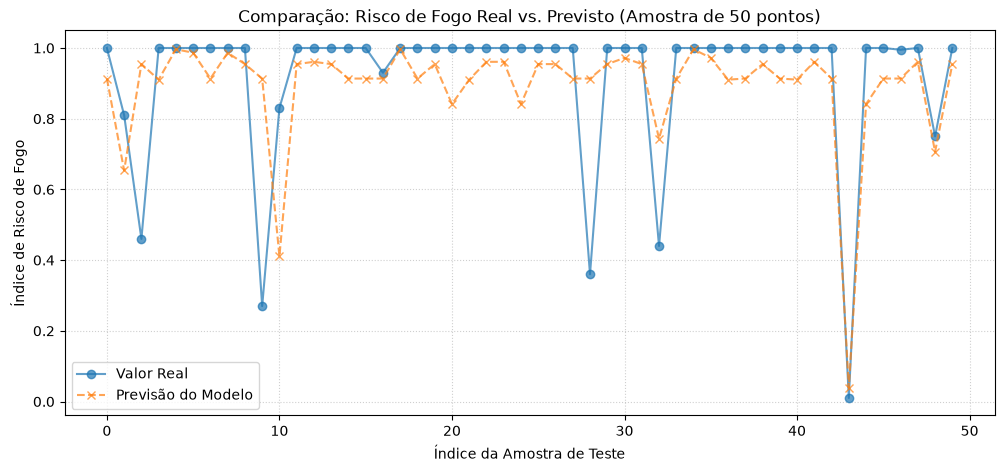

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Criar um DataFrame para alinhar os valores reais e previstos
# Utilizamos .values no y_test para ignorar os índices originais desordenados
df_comparacao = pd.DataFrame({
    'Valor Real': y_test.values,
    'Previsão': previsoes
})

# 2. Calcular a diferença absoluta (erro)
df_comparacao['Erro Absoluto'] = abs(df_comparacao['Valor Real'] - df_comparacao['Previsão'])

# 3. Mostrar as primeiras 15 previsões no ecrã
print("Tabela de Comparação (Primeiras 15 amostras):")
print(df_comparacao.head(15))

# 4. Criar um gráfico para visualizar os primeiros 50 casos
plt.figure(figsize=(12, 5))
plt.plot(df_comparacao['Valor Real'][0:50], label='Valor Real', marker='o', linestyle='-', alpha=0.7)
plt.plot(df_comparacao['Previsão'][0:50], label='Previsão do Modelo', marker='x', linestyle='--', alpha=0.7)

plt.title('Comparação: Risco de Fogo Real vs. Previsto (Amostra de 50 pontos)')
plt.xlabel('Índice da Amostra de Teste')
plt.ylabel('Índice de Risco de Fogo')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

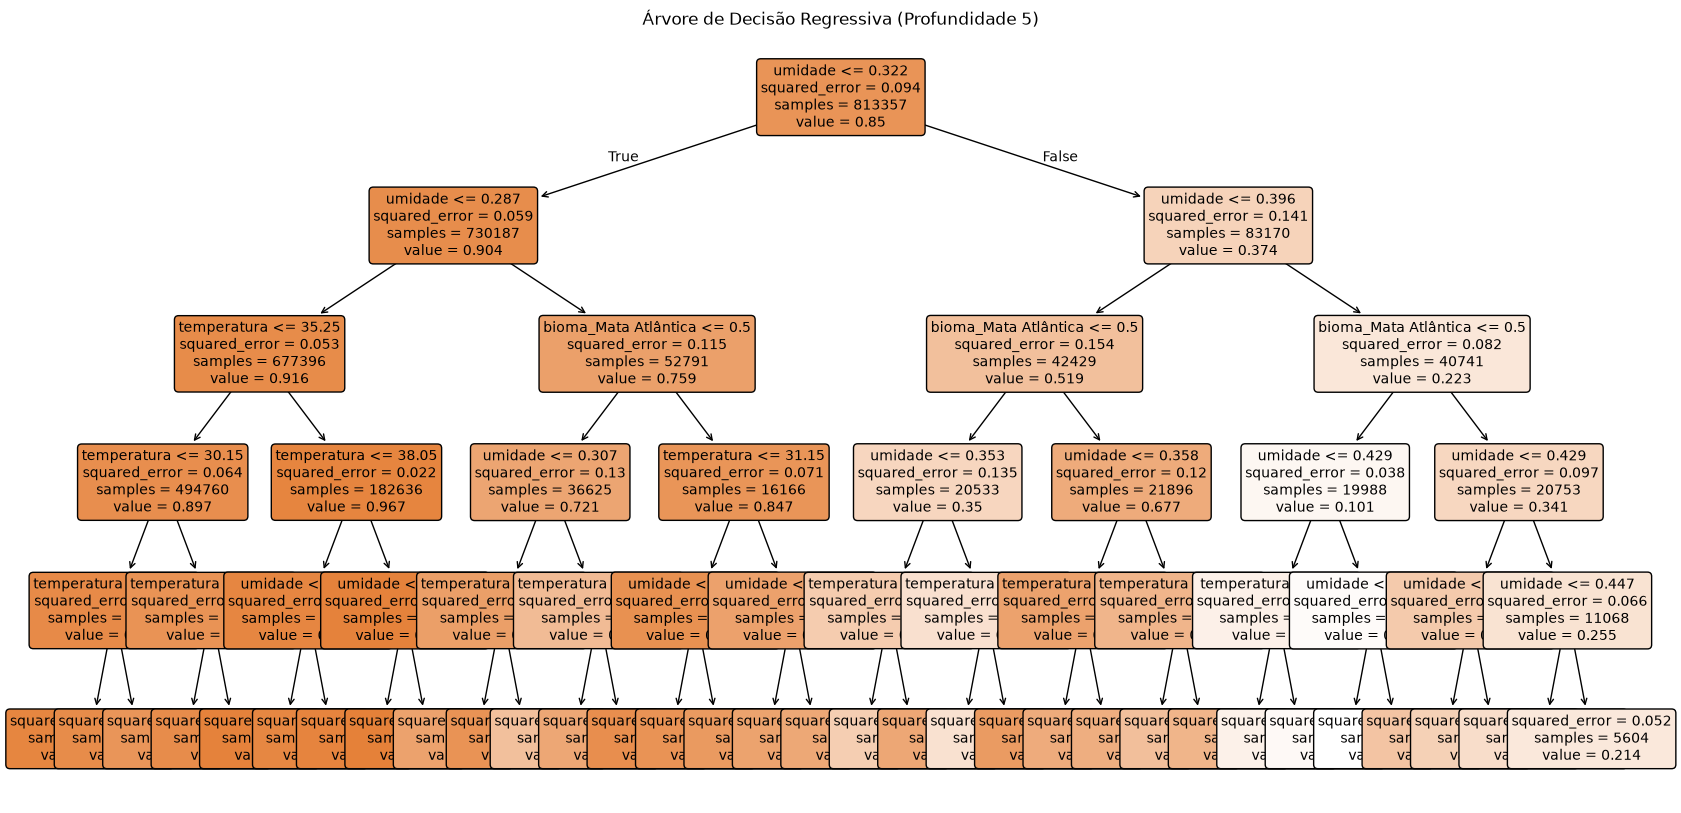

In [14]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Configurar o tamanho da imagem (largura, altura)
plt.figure(figsize=(20, 10))

# Desenhar a árvore limitando a 3 níveis de profundidade para não travar
plot_tree(modelo_arvore, 
          feature_names=X.columns, # Mostra o nome das colunas nas regras
          filled=True,             # Pinta as caixas
          rounded=True,            # Arredonda as bordas
          max_depth=5,             # LIMITADOR IMPORTANTE PARA ÁRVORES GRANDES
          fontsize=10)

plt.title("Árvore de Decisão Regressiva (Profundidade 5)")
plt.show()

In [15]:
from sklearn.tree import export_text

# Exportar as regras da árvore (limitado a profundidade 3 para leitura)
regras_arvore = export_text(modelo_arvore, 
                            feature_names=list(X.columns),
                            max_depth=5) # Mude para None para ver a árvore inteira

print("Regras da Árvore de Decisão:")
print(regras_arvore)

Regras da Árvore de Decisão:
|--- umidade <= 0.32
|   |--- umidade <= 0.29
|   |   |--- temperatura <= 35.25
|   |   |   |--- temperatura <= 30.15
|   |   |   |   |--- temperatura <= 21.85
|   |   |   |   |   |--- value: [0.96]
|   |   |   |   |--- temperatura >  21.85
|   |   |   |   |   |--- value: [0.91]
|   |   |   |--- temperatura >  30.15
|   |   |   |   |--- temperatura <= 34.15
|   |   |   |   |   |--- value: [0.84]
|   |   |   |   |--- temperatura >  34.15
|   |   |   |   |   |--- value: [0.91]
|   |   |--- temperatura >  35.25
|   |   |   |--- temperatura <= 38.05
|   |   |   |   |--- umidade <= 0.07
|   |   |   |   |   |--- value: [0.99]
|   |   |   |   |--- umidade >  0.07
|   |   |   |   |   |--- value: [0.95]
|   |   |   |--- temperatura >  38.05
|   |   |   |   |--- umidade <= 0.24
|   |   |   |   |   |--- value: [0.97]
|   |   |   |   |--- umidade >  0.24
|   |   |   |   |   |--- value: [1.00]
|   |--- umidade >  0.29
|   |   |--- bioma_Mata Atlântica <= 0.50
|   |   | 

*regressão linear*

In [16]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 1. Criar o Pipeline: Passo 1 (Escalonamento) -> Passo 2 (Modelo)
pipeline_regressao = Pipeline([
    ('escalonador', StandardScaler()), # Padroniza as variáveis para terem média 0 e desvio padrão 1
    ('modelo', LinearRegression())     # Inicializa a Regressão Linear
])

# 2. Treinar o Pipeline
# O fit vai automaticamente padronizar o X_train e depois treinar a Regressão Linear
pipeline_regressao.fit(X_train, y_train)

# 3. Fazer previsões
# O predict vai aplicar a mesma padronização no X_test antes de prever
previsoes_lr = pipeline_regressao.predict(X_test)

# 4. Avaliar o desempenho do modelo
mse_lr = mean_squared_error(y_test, previsoes_lr)
mae_lr = mean_absolute_error(y_test, previsoes_lr)
r2_lr = r2_score(y_test, previsoes_lr)

print(f"Erro Quadrático Médio (MSE) - Regressão Linear: {mse_lr:.4f}")
print(f"Erro Absoluto Médio (MAE) - Regressão Linear: {mae_lr:.4f}")
print(f"R² (Coeficiente de Determinação) - Regressão Linear: {r2_lr:.4f}")

Erro Quadrático Médio (MSE) - Regressão Linear: 0.0784
Erro Absoluto Médio (MAE) - Regressão Linear: 0.2056
R² (Coeficiente de Determinação) - Regressão Linear: 0.1550


In [17]:
# Extrair o modelo de dentro do pipeline
modelo_treinado = pipeline_regressao.named_steps['modelo']

# Criar um DataFrame para ver o peso (coeficiente) de cada coluna
import pandas as pd
coeficientes = pd.DataFrame({
    'Variável': X.columns,
    'Peso (Coeficiente)': modelo_treinado.coef_
}).sort_values(by='Peso (Coeficiente)', ascending=False)

print("\nImpacto de cada variável no Risco de Fogo:")
print(coeficientes)


Impacto de cada variável no Risco de Fogo:
               Variável  Peso (Coeficiente)
2  bioma_Mata Atlântica            0.009208
0           temperatura            0.004102
1               umidade           -0.121847


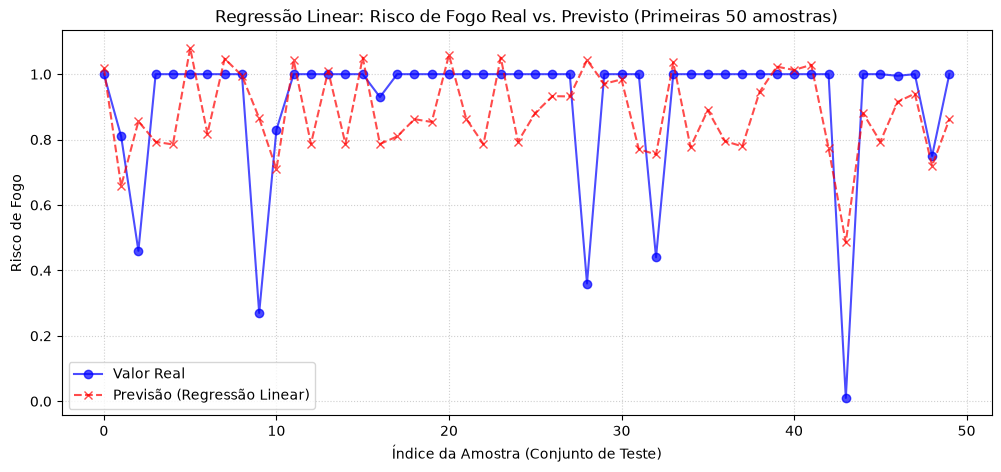

In [18]:
import matplotlib.pyplot as plt

# 1. Selecionar as primeiras 50 amostras
# Usa-se .values no y_test para garantir que o gráfico ignora os índices originais do DataFrame
y_test_amostra = y_test.values[:50]
previsoes_lr_amostra = previsoes_lr[:50]

# 2. Configurar e desenhar o gráfico
plt.figure(figsize=(12, 5))

# Linha dos valores reais
plt.plot(y_test_amostra, label='Valor Real', marker='o', linestyle='-', color='blue', alpha=0.7)

# Linha das previsões da Regressão Linear
plt.plot(previsoes_lr_amostra, label='Previsão (Regressão Linear)', marker='x', linestyle='--', color='red', alpha=0.7)

# 3. Adicionar detalhes visuais
plt.title('Regressão Linear: Risco de Fogo Real vs. Previsto (Primeiras 50 amostras)')
plt.xlabel('Índice da Amostra (Conjunto de Teste)')
plt.ylabel('Risco de Fogo')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# 4. Mostrar o gráfico
plt.show()

*regressão polinomial*

In [19]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.compose import ColumnTransformer # Importação necessária
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 1. Preparação dos dados (One-Hot Encoding)
# Supondo que seu df_colunas_prontas já esteja carregado
df_preparado = pd.get_dummies(df_colunas_prontas, columns=['bioma'], drop_first=True)

# 2. Separação de X e y
X = df_preparado.drop('risco_fogo', axis=1)
y = df_preparado['risco_fogo']

# 3. Divisão em Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# --- NOVO PASSO: Identificação das colunas ---
# Pega automaticamente as colunas que começam com 'bioma_' e as que não começam
colunas_bioma = [col for col in X.columns if col.startswith('bioma_')]
colunas_continuas = [col for col in X.columns if col not in colunas_bioma]

# 4. Construção do ColumnTransformer para isolar o Polinômio
transformador_colunas = ColumnTransformer(
    transformers=[
        # Aplica o polinômio APENAS nas colunas contínuas
        ('poly_num', PolynomialFeatures(degree=2, include_bias=False), colunas_continuas),
        # Deixa as colunas de bioma passarem direto para a próxima etapa ('passthrough')
        ('pass_cat', 'passthrough', colunas_bioma)
    ]
)

# 5. Construção do Pipeline Completo
pipeline_polinomial = Pipeline([
    ('transformacao_polinomial', transformador_colunas), # Cria polinômio das numéricas + junta com dummies
    ('escalonador', StandardScaler()),                   # Padroniza a nova matriz inteira (Crucial para o Ridge)
    ('modelo', Ridge(alpha=1.0))                         # Aplica a regressão
])

# 6. Treino do Pipeline
pipeline_polinomial.fit(X_train, y_train)

# 7. Realização de Previsões no conjunto de teste
previsoes_poly = pipeline_polinomial.predict(X_test)

# 8. Avaliação do Desempenho
mse_poly = mean_squared_error(y_test, previsoes_poly)
mae_poly = mean_absolute_error(y_test, previsoes_poly)
r2_poly = r2_score(y_test, previsoes_poly)

print(f"Erro Quadrático Médio (MSE): {mse_poly:.4f}")
print(f"Erro Absoluto Médio (MAE): {mae_poly:.4f}")
print(f"R² (Coeficiente de Determinação): {r2_poly:.4f}")

Erro Quadrático Médio (MSE): 0.0640
Erro Absoluto Médio (MAE): 0.1701
R² (Coeficiente de Determinação): 0.3098


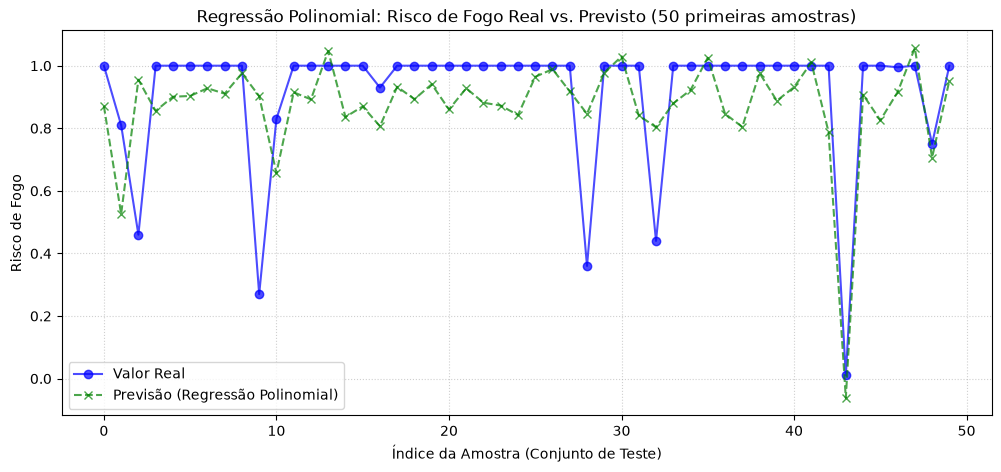

In [20]:
import matplotlib.pyplot as plt

# 1. Selecionar as 50 primeiras amostras
# Utilizamos .values no y_test para garantir que os índices desordenados sejam ignorados
y_test_amostra_poly = y_test.values[0:50]
previsoes_poly_amostra = previsoes_poly[0:50]

# 2. Criar e configurar o gráfico
plt.figure(figsize=(12, 5))

# Linha dos valores reais (Azul)
plt.plot(y_test_amostra_poly, label='Valor Real', marker='o', linestyle='-', color='blue', alpha=0.7)

# Linha das previsões polinomiais (Verde)
plt.plot(previsoes_poly_amostra, label='Previsão (Regressão Polinomial)', marker='x', linestyle='--', color='green', alpha=0.7)

# 3. Adicionar títulos, rótulos e legenda
plt.title('Regressão Polinomial: Risco de Fogo Real vs. Previsto (50 primeiras amostras)')
plt.xlabel('Índice da Amostra (Conjunto de Teste)')
plt.ylabel('Risco de Fogo')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# 4. Mostrar o gráfico na tela
plt.show()

*mlp regressora*

In [21]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 1. Preparação dos dados (One-Hot Encoding)
# Supondo que seu df_colunas_prontas já esteja carregado
df_preparado = pd.get_dummies(df_colunas_prontas, columns=['bioma'], drop_first=True)

# 2. Separação de X e y
X = df_preparado.drop('risco_fogo', axis=1)
y = df_preparado['risco_fogo']

# 3. Divisão em Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 4. Construção do Pipeline Completo
pipeline_mlp = Pipeline([
    ('escalonador', StandardScaler()),  # Padronização é obrigatória para o gradiente descendente da MLP
    ('modelo', MLPRegressor(
        hidden_layer_sizes=(64, 32),    # Arquitetura: 2 camadas ocultas (64 neurônios na 1ª, 32 na 2ª)
        activation='relu',              # Função de ativação ideal para regressão não-linear
        solver='adam',                  # Otimizador padrão e eficiente
        max_iter=1000,                  # Aumentado para 1000 para garantir que a rede tenha tempo de convergir
        random_state=42,
        early_stopping=True             # Para o treino cedo se não houver melhora, evitando overfitting
    )) 
])

# 5. Treino do Pipeline
pipeline_mlp.fit(X_train, y_train)

# 6. Realização de Previsões no conjunto de teste
previsoes_mlp = pipeline_mlp.predict(X_test)

# 7. Avaliação do Desempenho
mse_mlp = mean_squared_error(y_test, previsoes_mlp)
mae_mlp = mean_absolute_error(y_test, previsoes_mlp)
r2_mlp = r2_score(y_test, previsoes_mlp)

print(f"Erro Quadrático Médio (MSE) - MLP: {mse_mlp:.4f}")
print(f"Erro Absoluto Médio (MAE) - MLP: {mae_mlp:.4f}")
print(f"R² (Coeficiente de Determinação) - MLP: {r2_mlp:.4f}")

Erro Quadrático Médio (MSE) - MLP: 0.0556
Erro Absoluto Médio (MAE) - MLP: 0.1449
R² (Coeficiente de Determinação) - MLP: 0.4013


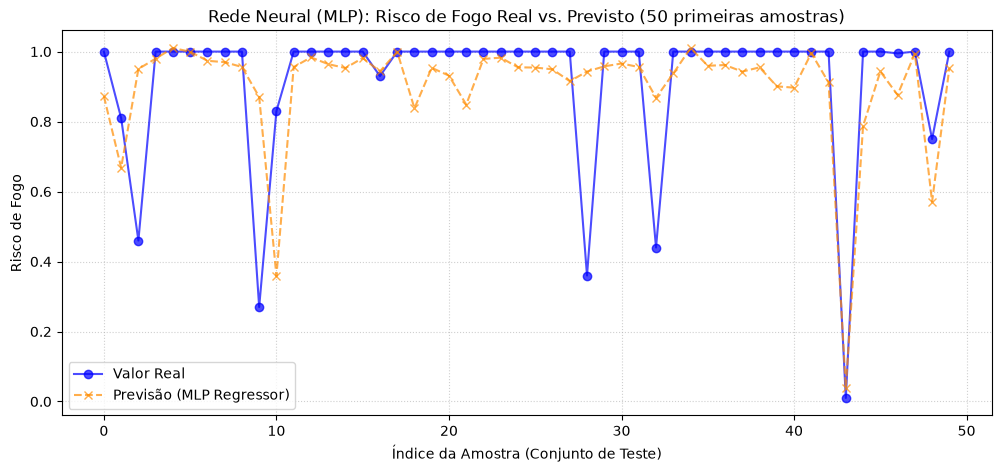

In [22]:
import matplotlib.pyplot as plt

# 1. Selecionar as 50 primeiras amostras
# Utilizamos .values no y_test para garantir que os índices desordenados sejam ignorados
y_test_amostra_mlp = y_test.values[0:50]
previsoes_mlp_amostra = previsoes_mlp[0:50]

# 2. Criar e configurar o gráfico
plt.figure(figsize=(12, 5))

# Linha dos valores reais (Azul)
plt.plot(y_test_amostra_mlp, label='Valor Real', marker='o', linestyle='-', color='blue', alpha=0.7)

# Linha das previsões da MLP (Laranja)
plt.plot(previsoes_mlp_amostra, label='Previsão (MLP Regressor)', marker='x', linestyle='--', color='darkorange', alpha=0.7)

# 3. Adicionar títulos, rótulos e legenda
plt.title('Rede Neural (MLP): Risco de Fogo Real vs. Previsto (50 primeiras amostras)')
plt.xlabel('Índice da Amostra (Conjunto de Teste)')
plt.ylabel('Risco de Fogo')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# 4. Mostrar o gráfico na tela
plt.show()

In [23]:
import joblib

# 1. Exportando a Árvore de Decisão
joblib.dump(modelo_arvore, 'modelo_arvore.pkl')

# 2. Exportando o Pipeline de Regressão Linear
joblib.dump(pipeline_regressao, 'pipeline_regressao.pkl')

# 3. Exportando o Pipeline de Regressão Polinomial
joblib.dump(pipeline_polinomial, 'pipeline_polinomial.pkl')

# 4. Exportando o Pipeline da Rede Neural (MLP Regressor)
joblib.dump(pipeline_mlp, 'pipeline_mlp.pkl')

print("Todos os modelos (.pkl) foram gerados e salvos com sucesso!")

Todos os modelos (.pkl) foram gerados e salvos com sucesso!
